In [17]:
# Cell 1: Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.18.0


Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


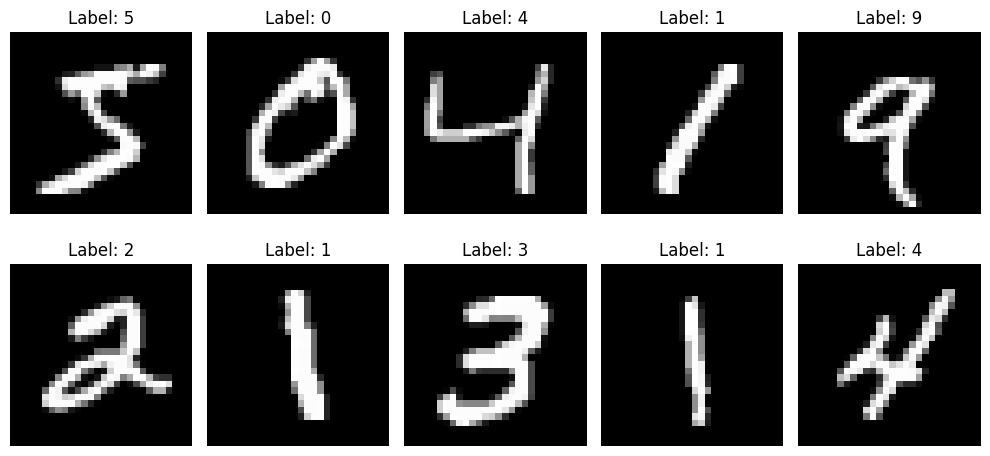

In [18]:
# Cell 2: Load MNIST Dataset
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Check dataset shape
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Display some sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# Cell 3: Preprocess the Data
# Normalize pixel values to range [0, 1] (originally 0-255)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape data for CNN input (add channel dimension)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Shape after reshaping:", x_train.shape)

# One-hot encode the labels
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print("Example label conversion:")
print(f"Original label: {y_train[0]}")
print(f"One-hot encoded: {y_train_categorical[0]}")

Shape after reshaping: (60000, 28, 28, 1)
Example label conversion:
Original label: 5
One-hot encoded: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [20]:
# Cell 4: Build the CNN Model
def create_cnn_model():
    """
    Create a CNN model for MNIST digit recognition.
    """
    model = keras.Sequential([
        # First convolutional block
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2, 2)),
        
        # Second convolutional block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Third convolutional block
        layers.Conv2D(64, (3, 3), activation='relu'),
        
        # Flatten and dense layers
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),  # Regularization
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create the model
model = create_cnn_model()

# Display model architecture
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Cell 5: Compile the Model
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully!")

Model compiled successfully!


In [22]:
# Cell 6: Train the Model
# Define training parameters
batch_size = 128
epochs = 10

# Train the model
history = model.fit(
    x_train, y_train_categorical,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.1,  # Use 10% of training data for validation
    verbose=1
)

Epoch 1/10


2025-12-28 12:42:23.164404: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7029 - loss: 0.8955 - val_accuracy: 0.9802 - val_loss: 0.0696
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9562 - loss: 0.1504 - val_accuracy: 0.9863 - val_loss: 0.0457
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9707 - loss: 0.1007 - val_accuracy: 0.9870 - val_loss: 0.0463
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9766 - loss: 0.0802 - val_accuracy: 0.9883 - val_loss: 0.0381
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9818 - loss: 0.0653 - val_accuracy: 0.9905 - val_loss: 0.0387
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9852 - loss: 0.0534 - val_accuracy: 0.9913 - val_loss: 0.0316
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9864 - loss: 0.0462 - val_accuracy: 0.9905 - val_loss: 0.0365
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9885 - loss: 0.0414 - val_accuracy: 0.9917 - val_

2025-12-28 12:43:05.552876: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Test Accuracy: 0.9934 (99.34%)
Test Loss: 0.0252


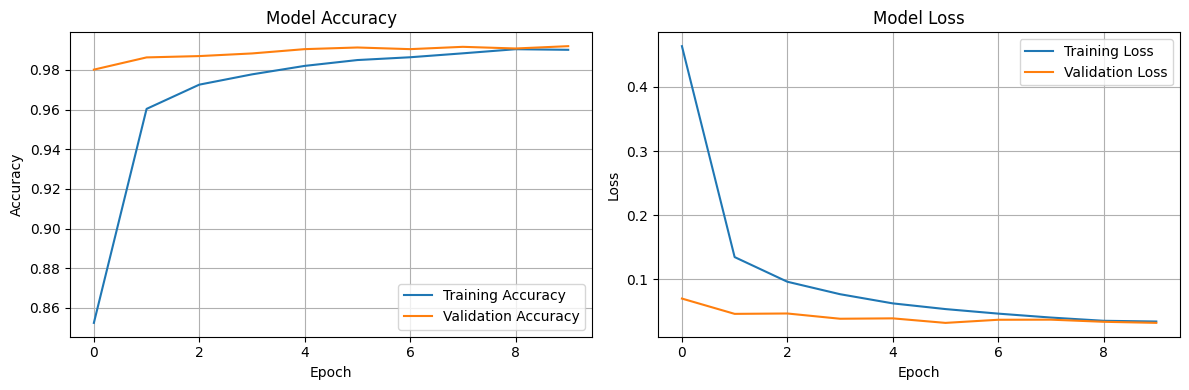

In [23]:
# Cell 7: Evaluate Model Performance
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Plot loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


2025-12-28 12:43:15.560500: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


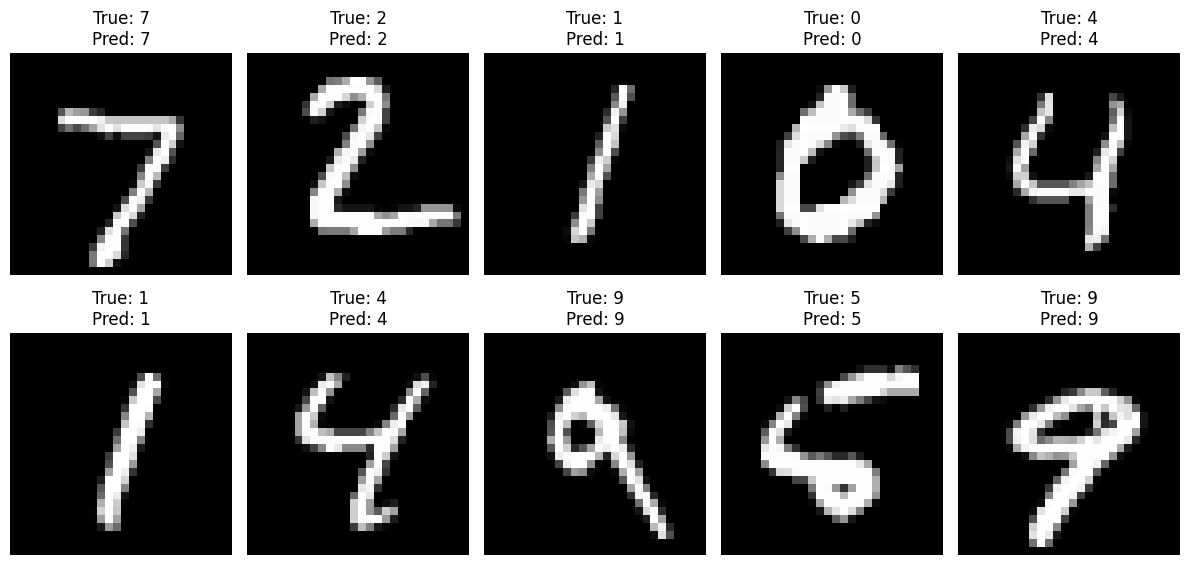

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


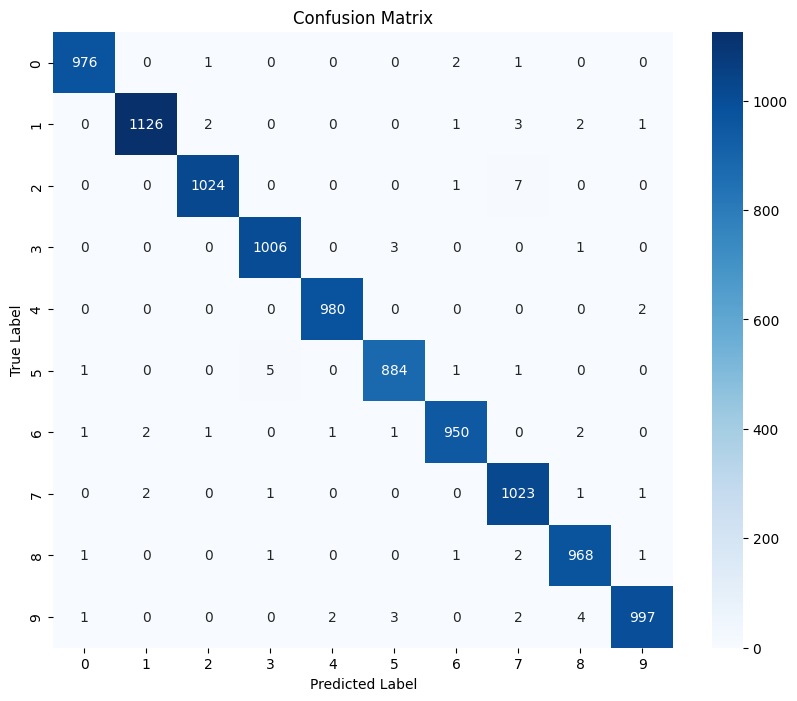


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [24]:
# Cell 8: Make Predictions and Display Results
# Make predictions on test data
predictions = model.predict(x_test[:10])
predicted_classes = np.argmax(predictions, axis=1)

# Display some predictions
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    
    # Highlight incorrect predictions in red
    if y_test[i] != predicted_classes[i]:
        plt.title(f"True: {y_test[i]}\nPred: {predicted_classes[i]}", color='red')
    else:
        plt.title(f"True: {y_test[i]}\nPred: {predicted_classes[i]}")
    
    plt.axis('off')
    
plt.tight_layout()
plt.show()

# Calculate and display confusion matrix
all_predictions = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, all_predictions))

In [25]:
# Cell 9: Save the Trained Model
# Create directory for saving models
os.makedirs('/kaggle/working/models', exist_ok=True)

# Save in the recommended .keras format (TensorFlow 2.x)
model.save('/kaggle/working/models/mnist_cnn_model.keras')
print("Model saved in .keras format: /kaggle/working/models/mnist_cnn_model.keras")

# Also save in H5 format for broader compatibility
model.save('/kaggle/working/models/mnist_cnn_model.h5')
print("Model saved in H5 format: /kaggle/working/models/mnist_cnn_model.h5")

# Save only the weights
model.save_weights('/kaggle/working/models/mnist_cnn_weights.weights.h5')
print("Weights saved: /kaggle/working/models/mnist_cnn_weights.weights.h5")

Model saved in .keras format: /kaggle/working/models/mnist_cnn_model.keras
Model saved in H5 format: /kaggle/working/models/mnist_cnn_model.h5
Weights saved: /kaggle/working/models/mnist_cnn_weights.weights.h5


In [26]:
# Cell 10: Test the Saved Model
# Load the saved model
loaded_model = keras.models.load_model('/kaggle/working/models/mnist_cnn_model.keras')

# Test the loaded model
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(x_test, y_test_categorical, verbose=0)
print(f"\nLoaded Model Test Accuracy: {loaded_test_accuracy:.4f} ({loaded_test_accuracy*100:.2f}%)")
print(f"Original Model Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Make a prediction with the loaded model
sample_image = x_test[0:1]
prediction = loaded_model.predict(sample_image)
predicted_class = np.argmax(prediction)
print(f"\nSample prediction - Predicted: {predicted_class}, Actual: {y_test[0]}")

2025-12-28 12:43:50.175522: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Loaded Model Test Accuracy: 0.9934 (99.34%)
Original Model Test Accuracy: 0.9934 (99.34%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step

Sample prediction - Predicted: 7, Actual: 7


In [27]:
# Cell 11: Prepare for Download and Create Summary
# List saved model files
print("Model files available for download:")
print("=" * 50)
for file in os.listdir('/kaggle/working/models'):
    filepath = os.path.join('/kaggle/working/models', file)
    filesize = os.path.getsize(filepath) / 1024  # Convert to KB
    print(f"  - {file}: {filesize:.2f} KB")

print("\nTo download the model files from Kaggle:")
print("1. Click on the 'Data' tab in the right sidebar")
print("2. Navigate to '/kaggle/working/models/'")
print("3. Select the model files and click 'Download'")
print("\nYou can also use the Kaggle API to download files programmatically.")

# Create a summary file
with open('/kaggle/working/models/model_info.txt', 'w') as f:
    f.write(f"MNIST CNN Model Summary\n")
    f.write("="*50 + "\n")
    f.write(f"Model Architecture: CNN with 3 Conv layers\n")
    f.write(f"Input Shape: (28, 28, 1)\n")
    f.write(f"Number of Classes: {num_classes}\n")
    f.write(f"Test Accuracy: {test_accuracy:.4f}\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Training Epochs: {epochs}\n")
    f.write(f"Batch Size: {batch_size}\n")
    f.write(f"\nSaved Files:\n")
    f.write(f"  - mnist_cnn_model.keras: Complete model (.keras format)\n")
    f.write(f"  - mnist_cnn_model.h5: Complete model (H5 format)\n")
    f.write(f"  - mnist_cnn_weights.weights.h5: Model weights only\n")
    f.write(f"\nTraining Parameters:\n")
    f.write(f"  - Optimizer: Adam\n")
    f.write(f"  - Loss Function: Categorical Crossentropy\n")
    f.write(f"  - Dropout Rate: 0.5\n")

print("\nModel summary saved to: /kaggle/working/models/model_info.txt")

Model files available for download:
  - mnist_cnn_weights.weights.h5: 1131.09 KB
  - mnist_cnn_model.h5: 1140.85 KB
  - mnist_cnn_model.keras: 1137.79 KB

To download the model files from Kaggle:
1. Click on the 'Data' tab in the right sidebar
2. Navigate to '/kaggle/working/models/'
3. Select the model files and click 'Download'

You can also use the Kaggle API to download files programmatically.

Model summary saved to: /kaggle/working/models/model_info.txt
